In [8]:
# expm_ode.py

In [32]:
###Importing Libraries###
import numpy as np
import matplotlib.pyplot as plt

In [33]:
### Defining Forward Euler Method Function
def forward_euler(f_ode, xRange, yInitial, numSteps):
    """
    x, y = forward_euler(f_ode, xRange, yInitial, numSteps)

    Use Euler's explicit method on one or more ODEs dy/dx = f_ode(x,y).

    Input:
    f_ode evaluates the right hand side.
    xRange = [x1, x2], the solution interval.
    yInitial = k initial values for y at x1
    numSteps = number of equally-sized steps to take from x1 to x2

    Output:
    x = numSteps+1 x values.
    y = numSteps+1 rows and k columns.
    """

    x = np.zeros(numSteps + 1)
    y = np.zeros((numSteps + 1, np.size(yInitial)))

    dx = (xRange[1] - xRange[0]) / numSteps

    for k in range(0, numSteps + 1):
        if k == 0:
            x[0] = xRange[0]
            y[0, :] = yInitial
        else:
            x[k] = x[k - 1] + dx
            y[k, :] = y[k - 1, :] + dx * f_ode(x[k - 1], y[k - 1, :])

    return x, y


In [34]:
def expm_ode(x, y):
    f_value = -y-3.0 * x
    return f_value

f_ode =expm_ode
xRange=np.array( [ 0.0, 2.0 ] )
yInit = 1.0
numSteps=10
x, y= forward_euler(f_ode , xRange, yInit , numSteps)


FORWARD EULER METHOD - ERROR ANALYSIS
ODE: dy/dx = -y - 3x, y(0) = 1
Exact solution at x=2.0: y(2) = -3.2706705664732256
k   numSteps   Step Size    Y[-1,0]            E[k]               E[k]/E[k+1]    
--------------------------------------------------------------------------------
0   10         0.200000     -3.2147483648      5.5922201673e-02   ---            
1   20         0.100000     -3.2431533092      2.7517257292e-02   2.0323         
2   40         0.050000     -3.2570243131      1.3646253343e-02   2.0165         
3   80         0.025000     -3.2638756108      6.7949556994e-03   2.0083         
4   160        0.012500     -3.2672801359      3.3904305891e-03   2.0042         
5   320        0.006250     -3.2689771133      1.6934532059e-03   2.0021         

CONVERGENCE ANALYSIS

Theory: Euler method is first order (error ∝ h)
Expected error ratio: When h is halved, error should approximately halve (ratio ≈ 2)

h: 0.200000 → 0.100000 (halved: 0.50)   Error ratio: 2.0323  (Expe

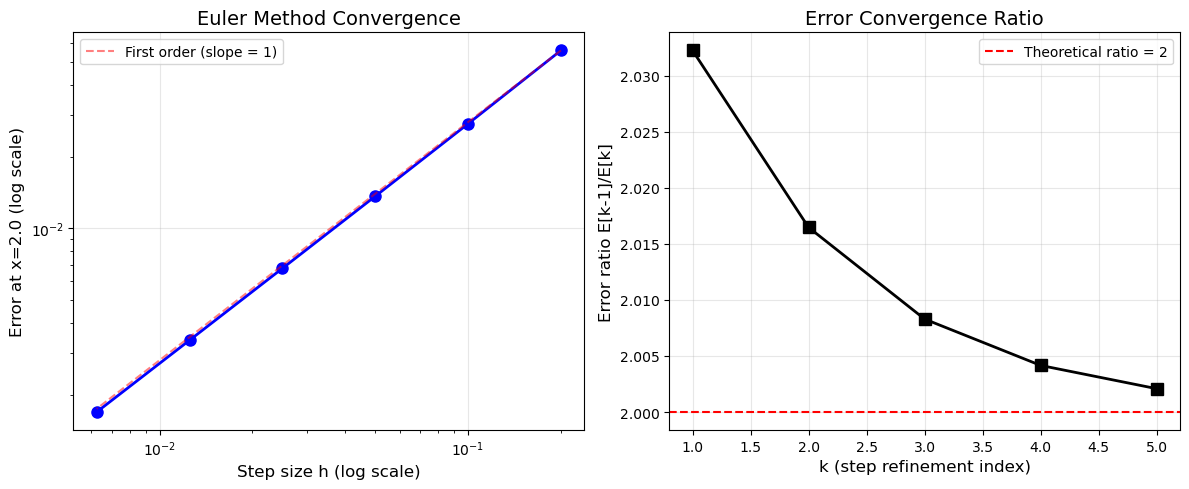


FINAL SUMMARY TABLE
k   numSteps   Step size    Y[-1,0]            E[k]               E[k]/E[k+1]    
--------------------------------------------------------------------------------
0   10         0.200000     -3.2147483648      5.5922201673e-02   ---            
1   20         0.100000     -3.2431533092      2.7517257292e-02   2.0323         
2   40         0.050000     -3.2570243131      1.3646253343e-02   2.0165         
3   80         0.025000     -3.2638756108      6.7949556994e-03   2.0083         
4   160        0.012500     -3.2672801359      3.3904305891e-03   2.0042         
5   320        0.006250     -3.2689771133      1.6934532059e-03   2.0021         

RAW RESULTS
0	10	0.200000	-3.2147483648	5.5922201673e-02	---
1	20	0.100000	-3.2431533092	2.7517257292e-02	2.0323
2	40	0.050000	-3.2570243131	1.3646253343e-02	2.0165
3	80	0.025000	-3.2638756108	6.7949556994e-03	2.0083
4	160	0.012500	-3.2672801359	3.3904305891e-03	2.0042
5	320	0.006250	-3.2689771133	1.6934532059e-03	2.0021


In [36]:
# ODE: dy/dx = -y - 3x, y(0) = 1
def expm_ode(x, y):
    return -y - 3.0 * x

# Exact solution: y(x) = -2e^(-x) - 3x + 3
def exact_solution(x):
    return -2 * np.exp(-x) - 3 * x + 3

# Parameters
xRange = np.array([0.0, 2.0])  # x from 0 to 2
yInit = 1.0                     # y(0) = 1

# 6 different numSteps values
numSteps_list = [10, 20, 40, 80, 160, 320]

# Arrays to store results
E = []          # Errors at x = 2.0
Y_final = []    # y values at final point

print("\n" + "="*80)
print("FORWARD EULER METHOD - ERROR ANALYSIS")
print("ODE: dy/dx = -y - 3x, y(0) = 1")
exact_at_2 = exact_solution(2.0)
print("Exact solution at x=2.0: y(2) =", exact_at_2)
print("="*80)

# Print header
print(f"{'k':<3} {'numSteps':<10} {'Step Size':<12} {'Y[-1,0]':<18} {'E[k]':<18} {'E[k]/E[k+1]':<15}")
print("-"*80)

# Calculate for each numSteps
for k, numSteps in enumerate(numSteps_list):
    h = float((xRange[1] - xRange[0]) / numSteps)
    
    # Solve using forward_euler
    x, y = forward_euler(expm_ode, xRange, yInit, numSteps)
    
    # Get final y value (at x = 2.0)
    if y.ndim > 1:
        y_final = float(y[-1, 0])  # For 2D array, convert to float
    else:
        y_final = float(y[-1])      # For 1D array, convert to float
    
    Y_final.append(y_final)
    
    # Calculate error at final point
    exact_val = exact_solution(2.0)
    error = abs(y_final - exact_val)
    E.append(error)
    
    # Calculate error ratio (skip for first row)
    if k == 0:
        ratio = "---"
        ratio_display = "---"
    else:
        ratio = E[k-1] / E[k]
        ratio_display = f"{ratio:.4f}"
    
    # Print row
    print(f"{k:<3} {numSteps:<10} {h:<12.6f} {y_final:<18.10f} {error:<18.10e} {ratio_display:<15}")

print("="*80)

# Additional convergence analysis
print("\n" + "="*80)
print("CONVERGENCE ANALYSIS")
print("="*80)
print("\nTheory: Euler method is first order (error ∝ h)")
print("Expected error ratio: When h is halved, error should approximately halve (ratio ≈ 2)\n")

for k in range(1, len(numSteps_list)):
    h_old = float((xRange[1] - xRange[0]) / numSteps_list[k-1])
    h_new = float((xRange[1] - xRange[0]) / numSteps_list[k])
    ratio = E[k-1] / E[k]
    h_ratio = h_new / h_old
    print(f"h: {h_old:.6f} → {h_new:.6f} (halved: {h_ratio:.2f})   Error ratio: {ratio:.4f}  (Expected: ~2.00)")

print("\n" + "="*80)

# Plot results

# Figure 1: Error vs step size
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
h_vals = [float((xRange[1] - xRange[0]) / n) for n in numSteps_list]
plt.loglog(h_vals, E, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Step size h (log scale)', fontsize=12)
plt.ylabel('Error at x=2.0 (log scale)', fontsize=12)
plt.title('Euler Method Convergence', fontsize=14)
plt.grid(True, alpha=0.3)

# Add reference line for first order convergence
ref_error = E[0] * (np.array(h_vals) / h_vals[0])
plt.loglog(h_vals, ref_error, 'r--', alpha=0.5, label='First order (slope = 1)')
plt.legend()
plt.grid(True, alpha=0.3)

# Figure 2: Error ratios
plt.subplot(1, 2, 2)
ratios = [E[i-1]/E[i] for i in range(1, len(E))]
plt.plot(range(1, len(ratios)+1), ratios, 'ks-', linewidth=2, markersize=8)
plt.axhline(y=2.0, color='r', linestyle='--', label='Theoretical ratio = 2')
plt.xlabel('k (step refinement index)', fontsize=12)
plt.ylabel('Error ratio E[k-1]/E[k]', fontsize=12)
plt.title('Error Convergence Ratio', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)
print(f"{'k':<3} {'numSteps':<10} {'Step size':<12} {'Y[-1,0]':<18} {'E[k]':<18} {'E[k]/E[k+1]':<15}")
print("-"*80)

for k in range(len(numSteps_list)):
    h = float((xRange[1] - xRange[0]) / numSteps_list[k])
    if k == 0:
        ratio_str = "---"
    else:
        ratio_str = f"{E[k-1]/E[k]:.4f}"
    
    print(f"{k:<3} {numSteps_list[k]:<10} {h:<12.6f} {Y_final[k]:<18.10f} {E[k]:<18.10e} {ratio_str:<15}")

print("="*80)

# Also print as a clean table without formatting issues
print("\n" + "="*80)
print("RAW RESULTS")
print("="*80)
for k in range(len(numSteps_list)):
    h = (xRange[1] - xRange[0]) / numSteps_list[k]
    if k == 0:
        ratio_str = "---"
    else:
        ratio_str = f"{E[k-1]/E[k]:.4f}"
    print(f"{k}\t{numSteps_list[k]}\t{h:.6f}\t{Y_final[k]:.10f}\t{E[k]:.10e}\t{ratio_str}")